In [ ]:
import json
from http.client import responses
from pathlib import Path
from typing import Any, Dict, Optional

import urllib3

# from .. import logger
from maploc.utils.geo import BoundaryBox

OSM_URL = "https://api.openstreetmap.org/api/0.6/map.json"


def get_osm(
    boundary_box: BoundaryBox,
    cache_path: Optional[Path] = None,
    overwrite: bool = False,
) -> Dict[str, Any]:
    if not overwrite and cache_path is not None and cache_path.is_file():
        return json.loads(cache_path.read_text())

    (bottom, left), (top, right) = boundary_box.min_, boundary_box.max_
    query = {"bbox": f"{left},{bottom},{right},{top}"}

    # logger.info("Calling the OpenStreetMap API...")
    result = urllib3.request("GET", OSM_URL, fields=query, timeout=10)
    if result.status != 200:
        error = result.info()["error"]
        raise ValueError(f"{result.status} {responses[result.status]}: {error}")

    if cache_path is not None:
        cache_path.write_bytes(result.data)
    return result.json()



OSM data saved to munich_osm_data.json


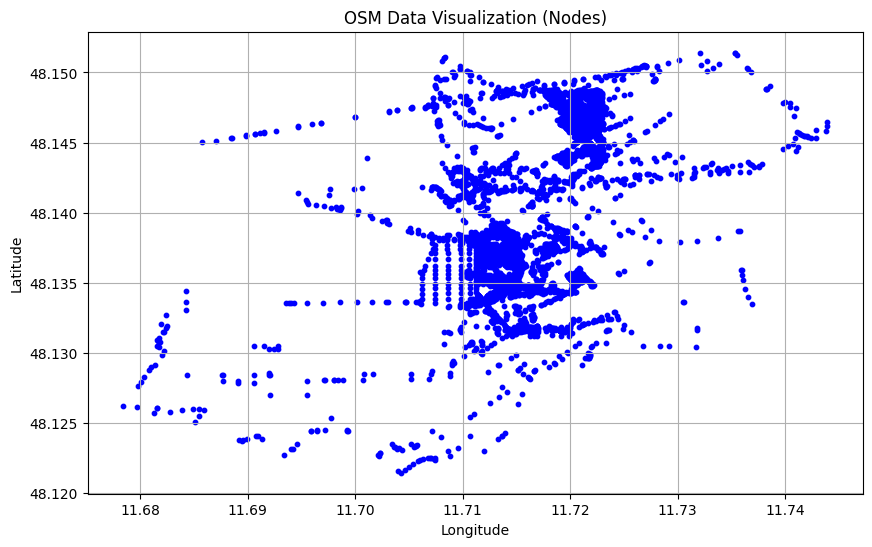

: 

In [5]:
import json
from http.client import responses
from pathlib import Path
from typing import Any, Dict, Optional

import urllib3
import matplotlib.pyplot as plt

# Define the OSM API URL
OSM_URL = "https://api.openstreetmap.org/api/0.6/map.json"

class BoundaryBox:
    def __init__(self, min_: tuple[float, float], max_: tuple[float, float]):
        self.min_ = min_
        self.max_ = max_

def get_osm(
    boundary_box: BoundaryBox,
    cache_path: Optional[Path] = None,
    overwrite: bool = False,
) -> Dict[str, Any]:
    if not overwrite and cache_path is not None and cache_path.is_file():
        return json.loads(cache_path.read_text())

    (bottom, left), (top, right) = boundary_box.min_, boundary_box.max_
    query = {"bbox": f"{left},{bottom},{right},{top}"}

    # Call the OSM API
    http = urllib3.PoolManager()
    result = http.request("GET", OSM_URL, fields=query, timeout=10)

    if result.status != 200:
        error = result.headers.get("error", "Unknown error")
        raise ValueError(f"{result.status} {responses[result.status]}: {error}")

    if cache_path is not None:
        cache_path.write_bytes(result.data)
    return json.loads(result.data)

def save_to_json(data: Dict[str, Any], file_path: Path):
    """Save the OSM data to a JSON file."""
    with file_path.open('w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

def visualize_osm_data(osm_data: Dict[str, Any]):
    """Visualize the OSM data."""
    if 'elements' not in osm_data:
        print("No 'elements' key in OSM data to visualize.")
        return
    
    latitudes = []
    longitudes = []
    
    for element in osm_data['elements']:
        if element['type'] == 'node':
            latitudes.append(element['lat'])
            longitudes.append(element['lon'])

    # Basic scatter plot of the node positions
    plt.figure(figsize=(10, 6))
    plt.scatter(longitudes, latitudes, marker='o', color='blue', s=10)
    plt.title("OSM Data Visualization (Nodes)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

# Define Munich's boundary box
munich_boundary_box = BoundaryBox(
    min_=(48.1316, 11.7102),  # Bottom-left (latitude, longitude)
    max_=(48.1487, 11.7229),  # Top-right (latitude, longitude)
)

# Example usage
osm_data = get_osm(munich_boundary_box)

# Save the OSM data to a JSON file
output_file = Path("munich_osm_data.json")
save_to_json(osm_data, output_file)
print(f"OSM data saved to {output_file}")

# Visualize the OSM data
visualize_osm_data(osm_data)


In [13]:
from nuscenes.nuscenes import NuScenes
import numpy as np

# 初始化nuScenes
nusc = NuScenes(version='v1.0-trainval', dataroot='D:\\Research\\Dataset\\Nuscenes\\v1.0-trainval', verbose=True)

# 提取所有ego vehicle的位置
gps_coords = []
for sample in nusc.sample:
    sample_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    gps_coords.append((ego_pose['translation'][0], ego_pose['translation'][1]))  # 这里是utm坐标系

print(gps_coords)

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 27.297 seconds.
Reverse indexing ...
Done reverse indexing in 6.4 seconds.
[(1010.1102882349232, 610.6567106479714), (1010.2642219746872, 612.7457909015482), (1010.0616806220463, 614.708717153934), (1009.4831449393264, 616.620003155022), (1008.4523418645251, 618.5256410102996), (1006.7152307896974, 620.602418179178), (1004.8563017236978, 622.3386866387929), (1003.1868077664784, 623.772338884165), (1001.0535195887503, 625.5918859601918), (998.8169322057958, 627.5026741637021), (996.5608330940794, 629.4446293893993), (994.3348022784536, 631.359000340172), (992.1817257305318, 633.2097630216495), (990.1543898468157, 634.94767460193), (988.3657893440474, 636.4787753204015), (986.4940809569673, 638.1059100545738), (984.7996957419

In [ ]:
# Boston Seaport
boston_seaport_origin = [42.336849169438615, -71.05785369873047]

# Singapore Onenorth
singapore_onenorth_origin = [1.2882100868743724, 103.78475189208984]

# Singapore Hollandvillage
singapore_hollandvillage_origin = [1.2993652317780957, 103.78217697143555]

# Singapore Queenstown
singapore_queenstown_origin = [1.2782562240223188, 103.76741409301758]


In [1]:
import geopandas as gpd

# 加载 Shapefile
shapefile_path = "D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\data_osm\\osm\\singapore-hollandvillage.shp"  # 修改为你的shapefile路径
gdf = gpd.read_file(shapefile_path)

# 获取 bounding box
bounding_box = gdf.total_bounds  # 这个会返回 (minx, miny, maxx, maxy)

# 输出 bounding box
print(f"Bounding box: {bounding_box}")


Bounding box: [103.7850828   1.304232  103.8127344   1.3271791]


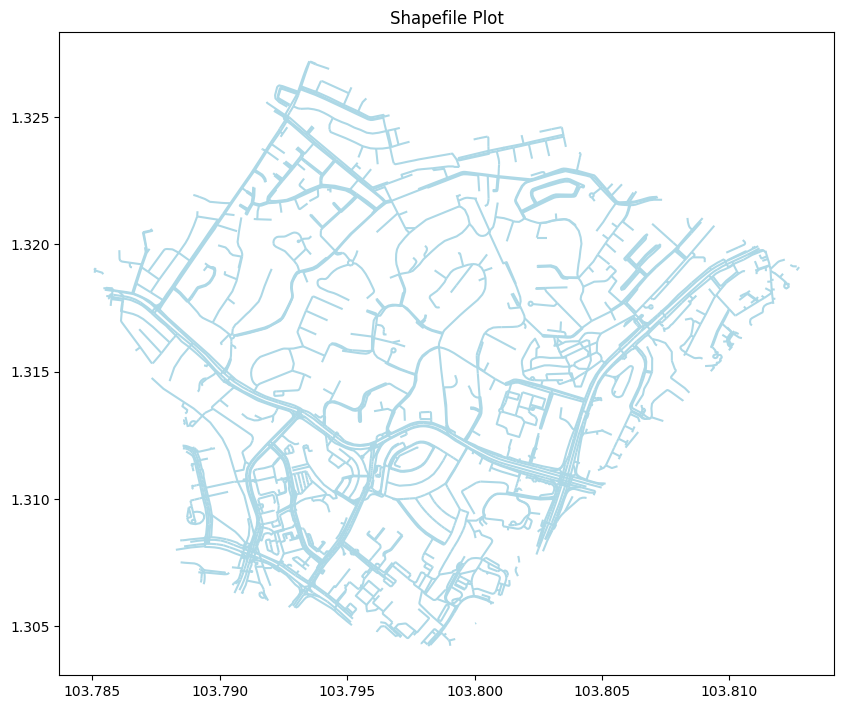

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 加载 .shp 文件
shapefile_path = "D:\GitHub\geo-localization-with-point-clouds-and-openstreetmap\data_osm\osm\singapore-hollandvillage.shp"  # 替换为实际的 .shp 文件路径
gdf = gpd.read_file(shapefile_path)

# 绘制 .shp 文件
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="lightblue", edgecolor="black")

# 设置标题和显示
ax.set_title("Shapefile Plot")
plt.show()


In [1]:
from ori_geo import TopocentricConverter
import geopandas as gpd
from shapely.geometry import LineString, box, MultiPolygon, MultiLineString
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import tqdm
import numpy as np

from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap

boston_seaport_origin = [42.336849169438615, -71.05785369873047]
singapore_onenorth_origin = [1.2882100868743724, 103.78475189208984]
singapore_hollandvillage_origin = [1.2993652317780957, 103.78217697143555]
singapore_queenstown_origin = [1.2782562240223188, 103.76741409301758]

sd_maps = {}
nusc_maps = {}
MAPS = ['boston-seaport','singapore-hollandvillage','singapore-onenorth', 'singapore-queenstown']
for loc in MAPS:
    nusc_maps[loc] = NuScenesMap(dataroot='D:\\Research\\Dataset\\Nuscenes', map_name=loc)
    # map_explorer[loc] = NuScenesMapExplorer(nusc_maps[loc])

options = [
            'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', # road
            'trunk_link', 'primary_link', 'secondary_link', 'tertiary_link'# road link
            'living_street',  'road',  # Special road  'service'
        ]
map_origin = {
            'boston-seaport':           (42.336849169438615, -71.05785369873047, 0.),
            'singapore-onenorth':       (1.2882100868743724, 103.78475189208984, 0.),
            'singapore-hollandvillage': (1.2993652317780957, 103.78217697143555, 0.),
            'singapore-queenstown':     (1.2782562240223188, 103.76741409301758, 0.)}
for loc in MAPS:
    lat, lon, alt = map_origin[loc]
    converter = TopocentricConverter(lat, lon, alt)

    sd_map = gpd.read_file(f"D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\data_osm\\osm\\{loc}.shp")
    sd_map = sd_map[sd_map['type'].isin(options)]
    sd_map_topo_list = []
    for _, row in sd_map.iterrows():
        tmp_sd_data = list(row.geometry.coords)
        tmp_sd_data_topo = [converter.to_topocentric(lonlat[1], lonlat[0], 0.)[:2] for lonlat in tmp_sd_data]
        sd_map_topo_list.append(tmp_sd_data_topo)
    sd_maps = MultiLineString(sd_map_topo_list)

    fig, ax = nusc_maps[loc].render_layers(nusc_maps[loc].non_geometric_layers, figsize=1)
    lines = LineCollection([list(line.coords) for line in sd_maps])
    ax.add_collection(lines)
    ax.axis('equal')
    plt.savefig(f'{loc}.png', dpi=600)
    # plt.show()
    plt.close()
    # ENU --> ECEF


    # ECEF --> EPSG:4326 (WGS84)


c:\Users\kangs\anaconda3\envs\loc\lib\site-packages\descartes\patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
c:\Users\kangs\anaconda3\envs\loc\lib\site-packages\descartes\patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])
C:\Users\kangs\AppData\Local\Temp\ipykernel_42456\2383799490.py:49: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  lines = LineCollection([list(line.coords) for line in sd_maps])
c:\Users\kangs\anaconda3\envs\loc\lib\site-packages\descartes\patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no lo

In [8]:
nusc_map = NuScenesMap(dataroot='D:\\Research\\Dataset\\Nuscenes', map_name='singapore-onenorth')
nusc_map.line[0]

{'token': '98c91318-5854-41ac-9210-001b57b8185f',
 'node_tokens': ['4e2605d4-b9f4-41f9-a03c-032c8d4a3c24',
  '1cbbdda6-5ee6-4b4d-8bcc-30af18094978']}

In [10]:
nusc_map._token2ind('4e2605d4-b9f4-41f9-a03c-032c8d4a3c24')

TypeError: 'dict' object is not callable